## Autoencoders Lab
#### visualizing HapMap phase 3 populations

**This is a solution template. Every chunk of code requiring your input will begin with the # TASK comment and all places where you should fill-in with your code are marked by ellipsis (...).**

### Stage 0 &mdash; getting the data

First, we will download the data from the linked Dropbox account. The code is hidden as it is not super important here. Double-click below if you are curious to see it!



In [ ]:
#@title Load raw data. Double click to see the code. { display-mode: "form" }

!wget https://www.dropbox.com/s/g7862q1l4ls9z3x/autosomal_5k_matrix.csv
!wget https://www.dropbox.com/s/3lv0062dw20qdqg/autosomal_5k_phenos.csv
!wget https://www.dropbox.com/s/6nzrusxkm536a5j/autosomal_5k_kinship.csv

Now, we will load the data and make sure they look as expected. Note, the genotypes per individual (row) are encoded as the count of minor alleles and thus can take values `gt = {0, 1, 2}`.

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from matplotlib import pyplot as plt


In [5]:

data = pd.read_csv("autosomal_5k_matrix.csv", header=0, index_col=0)
pheno = pd.read_csv("autosomal_5k_phenos.csv", header=0, index_col=0)

print(data)


         rs416967  rs17013842  rs13052452  rs11049986  rs10994341  rs1504289  \
NA19919         2           1           0           1           1          0   
NA19916         1           0           0           1           1          0   
NA19835         0           0           1           1           0          1   
NA20282         1           1           0           1           0          0   
NA19703         0           0           0           0           1          1   
...           ...         ...         ...         ...         ...        ...   
NA19119         1           0           1           0           1          1   
NA18860         1           0           0           1           1          0   
NA19207         2           0           0           0           1          0   
NA19103         1           0           1           0           0          0   
NA19099         0           0           1           1           0          1   

         rs882529  rs3885937  rs537330 

In [6]:
print(pheno)


              id  sex   FID      dad      mom  pheno population
NA19919  NA19919    1  2427  NA19908  NA19909      0        ASW
NA19916  NA19916    1  2431        0        0      0        ASW
NA19835  NA19835    0  2424        0        0      0        ASW
NA20282  NA20282    0  2469        0        0      0        ASW
NA19703  NA19703    1  2368        0        0      0        ASW
...          ...  ...   ...      ...      ...    ...        ...
NA19119  NA19119    1  Y060        0        0      0        YRI
NA18860  NA18860    1  Y012  NA18859  NA18858      0        YRI
NA19207  NA19207    1  Y051        0        0      0        YRI
NA19103  NA19103    1  Y042  NA19101  NA19102      0        YRI
NA19099  NA19099    0  Y105        0        0      0        YRI

[1184 rows x 7 columns]


In [8]:
# Task 1: Examine the data
print("Loci names example:", data.columns[:5].tolist())
print("Total individuals:", len(pheno))
print("\nIndividuals per population:\n", pheno['population'].value_counts())
print("\nOverall sex distribution (0=Female, 1=Male):\n", pheno['sex'].value_counts())


Loci names example: ['rs416967', 'rs17013842', 'rs13052452', 'rs11049986', 'rs10994341']
Total individuals: 1184

Individuals per population:
 population
MKK    171
YRI    167
CEU    165
LWK     90
GIH     88
TSI     88
JPT     86
CHD     85
CHB     84
ASW     83
MEX     77
Name: count, dtype: int64

Overall sex distribution (0=Female, 1=Male):
 sex
0    595
1    589
Name: count, dtype: int64


We cannot tell the chromosome locus because the loci names (e.g., rs416967) are just Reference SNP cluster IDs (rsIDs).

In [9]:
print("\nSex distribution by population:\n", pd.crosstab(pheno['population'], pheno['sex']))
print("\nNumber of unique families (FID):", pheno['FID'].nunique())

# Check for siblings (founders have '0' for parents)
full_sibs = pheno[(pheno['dad'] != '0') & (pheno['mom'] != '0')].groupby(['dad', 'mom']).size()
print(f"\nFull sibling groups: {(full_sibs > 1).sum()}")
dads = pheno[pheno['dad'] != '0'].groupby('dad')['mom'].nunique()
moms = pheno[pheno['mom'] != '0'].groupby('mom')['dad'].nunique()
print(f"Half-sibling groups (shared dad): {(dads > 1).sum()}")
print(f"Half-sibling groups (shared mom): {(moms > 1).sum()}")



Sex distribution by population:
 sex          0   1
population        
ASW         45  38
CEU         85  80
CHB         42  42
CHD         44  41
GIH         43  45
JPT         42  44
LWK         45  45
MEX         43  34
MKK         85  86
TSI         44  44
YRI         77  90

Number of unique families (FID): 770

Full sibling groups: 0
Half-sibling groups (shared dad): 0
Half-sibling groups (shared mom): 0


Now, we will create a dictionary and re-name our populations so that the names are a bit more informative:

In [10]:
pop_dict = {'ASW':'African ancestry in SW USA',
            'CEU':'Utah residents with N and W European ancestry',
            'CHB':'Han Chinese in Beijing China',
            'CHD':'Chinese in Metropolitan Denver Colorado',
            'GIH':'Gujarati Indians in Houston Texas',
            'JPT':'Japanese in Tokyo Japan',
            'LWK':'Luhya in Webuye Kenya',
            'MEX':'Mexican ancestry in Los Angeles California',
            'MKK':'Maasai in Kinyawa Kenya',
            'TSI':'Toscans in Italy',
            'YRI':'Yoruba in Ibadan Nigeria'}
pheno2 = pheno.replace({"population": pop_dict})
pheno2

,id,sex,FID,dad,mom,pheno,population
NA19919,NA19919,1,2427,NA19908,NA19909,0,African ancestry in SW USA
NA19916,NA19916,1,2431,0,0,0,African ancestry in SW USA
NA19835,NA19835,0,2424,0,0,0,African ancestry in SW USA
NA20282,NA20282,0,2469,0,0,0,African ancestry in SW USA
NA19703,NA19703,1,2368,0,0,0,African ancestry in SW USA
...,...,...,...,...,...,...,...
NA19119,NA19119,1,Y060,0,0,0,Yoruba in Ibadan Nigeria
NA18860,NA18860,1,Y012,NA18859,NA18858,0,Yoruba in Ibadan Nigeria
NA19207,NA19207,1,Y051,0,0,0,Yoruba in Ibadan Nigeria
NA19103,NA19103,1,Y042,NA19101,NA19102,0,Yoruba in Ibadan Nigeria


In [11]:
# TASK Scaling
# We need to scale our counts data so that it is bound between 0 and 1.

geno_data = data / 2.0
geno_data

,rs416967,rs17013842,rs13052452,rs11049986,rs10994341,rs1504289,rs882529,rs3885937,rs537330,rs9372090,...,rs1558766,rs7818288,rs1051685,rs11223492,rs789492,rs6557516,rs7313246,rs317892,rs11937009,rs2806497
NA19919,1.0,0.5,0.0,0.5,0.5,0.0,0.0,0.5,0.5,0.5,...,0.0,0.5,0.0,0.0,0.5,0.0,0.5,0.5,0.5,0.0
NA19916,0.5,0.0,0.0,0.5,0.5,0.0,0.5,0.5,1.0,0.5,...,0.0,0.0,0.0,0.0,0.0,0.5,0.5,0.5,0.5,0.0
NA19835,0.0,0.0,0.5,0.5,0.0,0.5,0.0,1.0,1.0,0.5,...,0.0,0.5,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
NA20282,0.5,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.5,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,1.0,0.0,0.0
NA19703,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.0,1.0,...,0.0,0.5,0.5,0.0,0.5,0.5,0.5,0.5,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA19119,0.5,0.0,0.5,0.0,0.5,0.5,0.5,0.5,0.5,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0
NA18860,0.5,0.0,0.0,0.5,0.5,0.0,0.0,0.5,1.0,0.5,...,0.5,0.5,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.5
NA19207,1.0,0.0,0.0,0.0,0.5,0.0,0.5,0.5,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,0.5,0.0
NA19103,0.5,0.0,0.5,0.0,0.0,0.0,0.5,0.5,1.0,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.5,1.0,0.0


In [12]:
# TASK Randomly split into the training and the validation set, so that 80 per-cent of individuals ends up in the training set.

train = geno_data.sample(frac = 0.8, random_state = 42)
test = geno_data.drop(train.index)
train.reset_index()
test.reset_index()

# TASK Print some info about the resulting split
print("Total number of individuals:", len(geno_data))
print("\t - training set:", len(train))
print("\t - test set:", len(test))

Total number of individuals: 1184
	 - training set: 947
	 - test set: 237


In [13]:
# TASK Specify the autoencoder model

train_tensor = train.to_numpy()
print(type(train_tensor))

# TASK Hyperparameters
# use ReLu activations, ADAM optimizer and
# mean squared error as the loss function
hp_loss_fn = 'mse'
hp_act_fn = 'relu'
hp_optimizer = 'adam'
hp_metrics = ['mse','mae','mape']

input_data = keras.Input(shape = (train_tensor.shape[1],))

# TASK Define architecture of the encoder:
# the second layer should be a batch normalization

def Encoder(input):
  # Encoder
  layer1 = layers.Dense(units = 1500, activation = hp_act_fn, name='layer1')(input)
  layer2 = layers.BatchNormalization(name='layer2')(layer1)
  layer3 = layers.Dropout(rate = 0.05, name='layer3')(layer2)
  layer4 = layers.Dense(units = 250, activation = hp_act_fn, name='layer4')(layer3)
  layer5 = layers.Dropout(rate = 0.025, name='layer5')(layer4)
  layer6 = layers.Dense(units = 25, activation = hp_act_fn, name='layer6')(layer5)
  bottleneck = layers.Dense(units = 2, name='layer_bottleneck')(layer6)
  return(bottleneck)

# TASK Look at the encoder, complete the decoder function

def Decoder(bottleneck):
  # Decoder
  layer7 = layers.Dense(units = 25, activation = hp_act_fn)(bottleneck)
  layer8 = layers.Dropout(rate = 0.025)(layer7)
  layer9 = layers.Dense(units = 250, activation = hp_act_fn)(layer8)
  layer10 = layers.Dropout(rate = 0.05)(layer9)
  layer11 = layers.Dense(units = 1500, activation = hp_act_fn)(layer10)
  layer12 = layers.Dense(units = train_tensor.shape[1], activation = 'sigmoid')(layer11)
  return(layer12)

def Autoencoder(input):
  enc = Encoder(input)
  autoenc = Decoder(enc)
  return(autoenc)

autoencoder_model = keras.Model(inputs = input_data, outputs = Autoencoder(input_data))
autoencoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics
)

# TASK Visualise the created architecture and summarise its parameters
autoencoder_model.summary()

<class 'numpy.ndarray'>


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer1 (Dense)                  │ (None, 1500)           │     7,501,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (BatchNormalization)     │ (None, 1500)           │         6,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dropout)                │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 250)            │       375,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer5 (Dropout)                │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer6 (Dense)                  │ (None, 25)             │         6,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_bottleneck (Dense)        │ (None, 2)              │            52 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │            75 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 250)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1500)           │       376,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5000)           │     7,505,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,777,152 (60.19 MB)

 Trainable params: 15,774,152 (60.17 MB)

 Non-trainable params: 3,000 (11.72 KB)

In [14]:
# TASK Set hyperparameters for model fitting
# Begin by training for 30 epochs, with mini-batch of 256 and validation set
# having 20 per-cent of examples

hp_epochs = 30
hp_batch_size = 256
hp_val_split = 0.2


autoencoder = autoencoder_model.fit(x = train_tensor,
                      y = train_tensor,
                      epochs = hp_epochs,
                      batch_size = hp_batch_size,
                      shuffle = True,
                      validation_split = hp_val_split,
                      )

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 705ms/step - loss: 0.1829 - mae: 0.3694 - mape: 338975296.0000 - mse: 0.1829 - val_loss: 0.1798 - val_mae: 0.3660 - val_mape: 335464416.0000 - val_mse: 0.1798
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 561ms/step - loss: 0.1404 - mae: 0.3305 - mape: 281365088.0000 - mse: 0.1404 - val_loss: 0.1155 - val_mae: 0.3088 - val_mape: 249362576.0000 - val_mse: 0.1155
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 556ms/step - loss: 0.0809 - mae: 0.1961 - mape: 71433352.0000 - mse: 0.0809 - val_loss: 0.0712 - val_mae: 0.1895 - val_mape: 86990016.0000 - val_mse: 0.0712
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 700ms/step - loss: 0.0809 - mae: 0.1645 - mape: 46380208.0000 - mse: 0.0809 - val_loss: 0.0748 - val_mae: 0.1753 - val_mape: 81349888.0000 - val_mse: 0.0748
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 729ms/step - loss: 0.0766 - mae: 0.1677 - mape: 63273108.0000 - mse: 0.0766 - val_loss: 0.0732 - val_mae: 0.1824 - val_mape: 87746120.0000 - val_mse: 0.0732
Epoch 6/30
3/3 ━

Now, let us look at the training process:

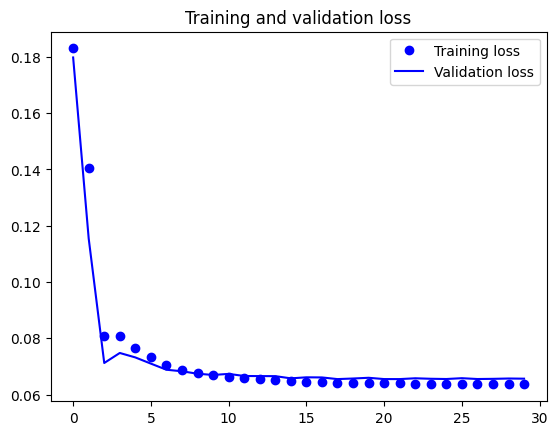

In [15]:
loss = autoencoder.history['loss']
val_loss = autoencoder.history['val_loss']
epochs = range(hp_epochs)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Now, that the model is trained, we can save the weights and use them to build an encoder. Note that weights are saved for the entire autoencoder, so we need to use `skip_mismatch = True` along with `by_name = True` to initialize weights in our encoder.

In [16]:
autoencoder_model.save_weights('autoencoder_weights.weights.h5',
                               overwrite = True)

encoder_model = keras.Model(inputs = input_data, outputs = Encoder(input_data))
encoder_model.load_weights('autoencoder_weights.weights.h5',
                           skip_mismatch = True)
encoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics,
)


Let us embed our genotyping data using the encoder we have just constructed.
We can also visualise the embedding.

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
[[  3.922213  -10.017924 ]
 [  3.7826278  -9.302279 ]
 [  2.4999263 -10.252232 ]
 ...
 [  3.9286141 -10.455215 ]
 [  4.6688004 -10.400274 ]
 [  5.1398525 -10.139457 ]]


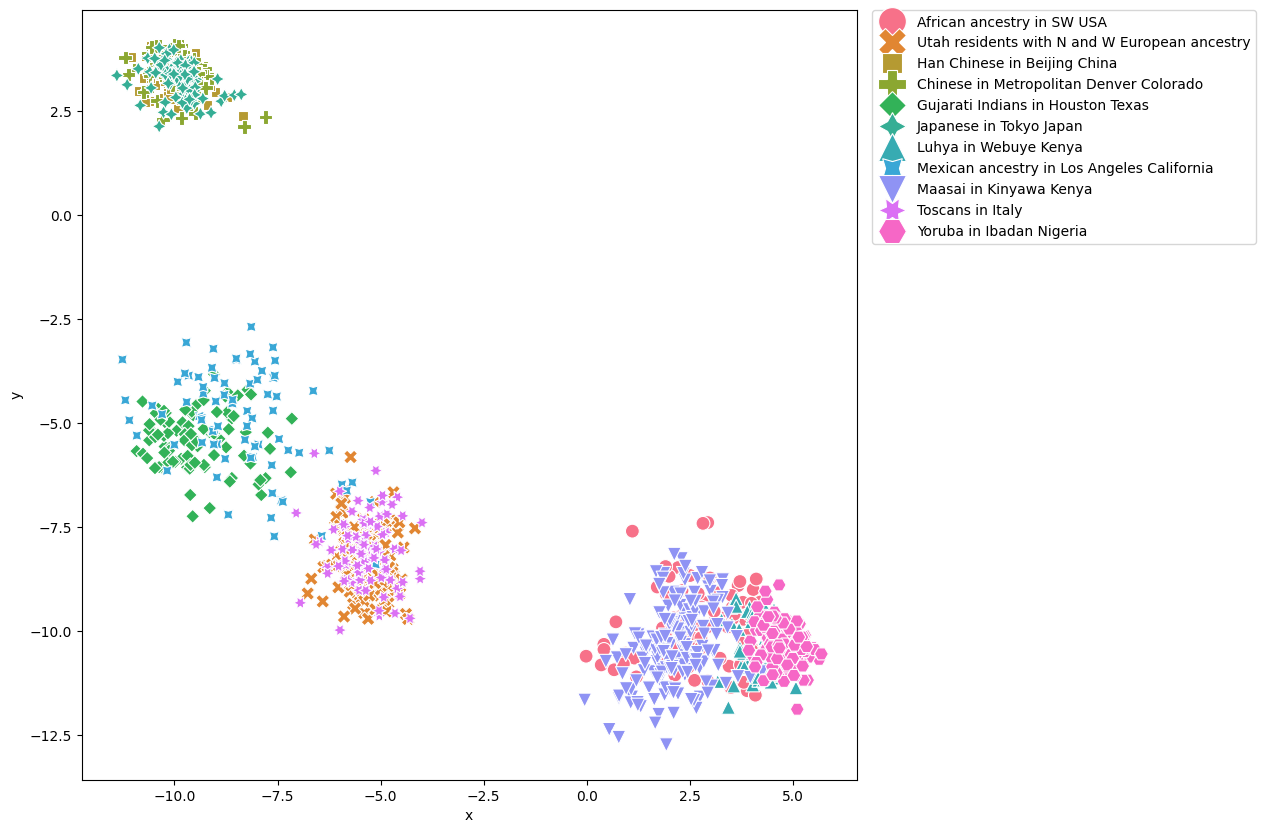

In [17]:
embeded_points = encoder_model.predict(geno_data.to_numpy())
print(embeded_points)

x = embeded_points[:,0]
y = embeded_points[:,1]
pop = pheno2['population']
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

Now, we will compare the result with:
* MDS on the kinship matrix
* PCA perfored directly on raw genotypes


In [18]:
kinship = pd.read_csv("autosomal_5k_kinship.csv", header=0, index_col=0)


In [19]:
from sklearn.manifold import MDS
embedding = MDS(n_components=2)
mds_embedding = embedding.fit_transform(kinship)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:632: UserWarning: The MDS API has changed. ``fit`` now constructs an dissimilarity matrix from data. To use a custom dissimilarity matrix, set ``dissimilarity='precomputed'``.
  warnings.warn(


<Axes: xlabel='x', ylabel='y'>

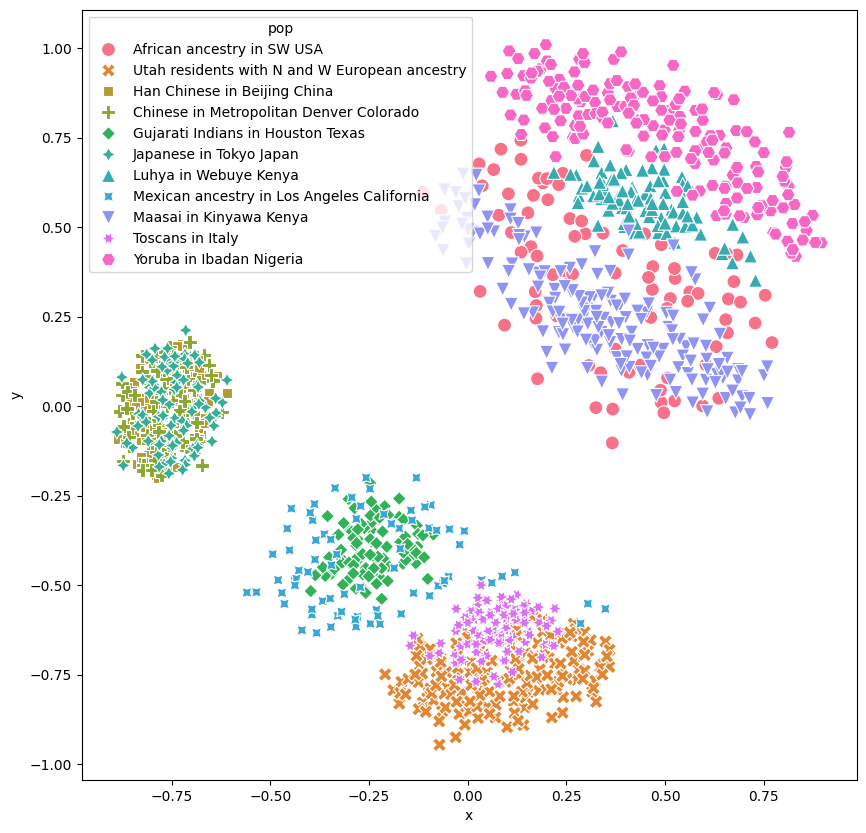

In [20]:
# TASK Plot MDS embedding in a way similar to plotting autoencoder embeddings
x = mds_embedding[:, 0]
y = mds_embedding[:, 1]
data_mds = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data_mds, hue='pop', style='pop', s=100)

Finally, we will perform PCA on raw genotypes:

<Axes: xlabel='x', ylabel='y'>

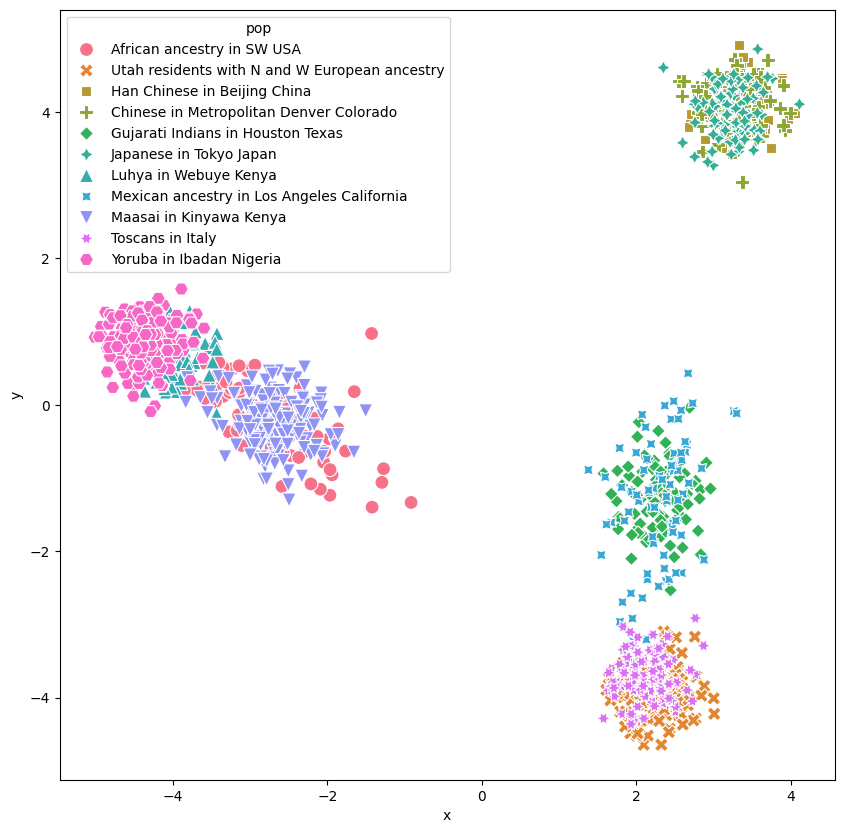

In [21]:
# TASK perform PCA with 2 components on raw genotypes (use geno_data as input but remember it has been scaled)
# Visualise the result.
from sklearn.decomposition import PCA
embedding = PCA(n_components=2)
pca_embedding = embedding.fit_transform(geno_data.to_numpy())
x = pca_embedding[:, 0]
y = pca_embedding[:, 1]
data_pca = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data_pca, hue='pop', style='pop', s=100)

### Discussion

- MDS on the kinship matrix and PCA on raw genotypes will yield nearly identical topological embeddings since they capture linear correlations and are mathematically related. Autoencoders can discover non-linear relationships, potentially resulting in tighter distinct clusters Meanwhile,they typically have similar macroscopic resolution, successfully separating the distinct continental ancestries.

### Task 4 : Experiment with Autoencoder

- Reduce neurons in the network -> giving less time to trained (I can use my local environment)

- Reducing layer dimensions act as heavier regularization, potentially improving the loss on the validation set.

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


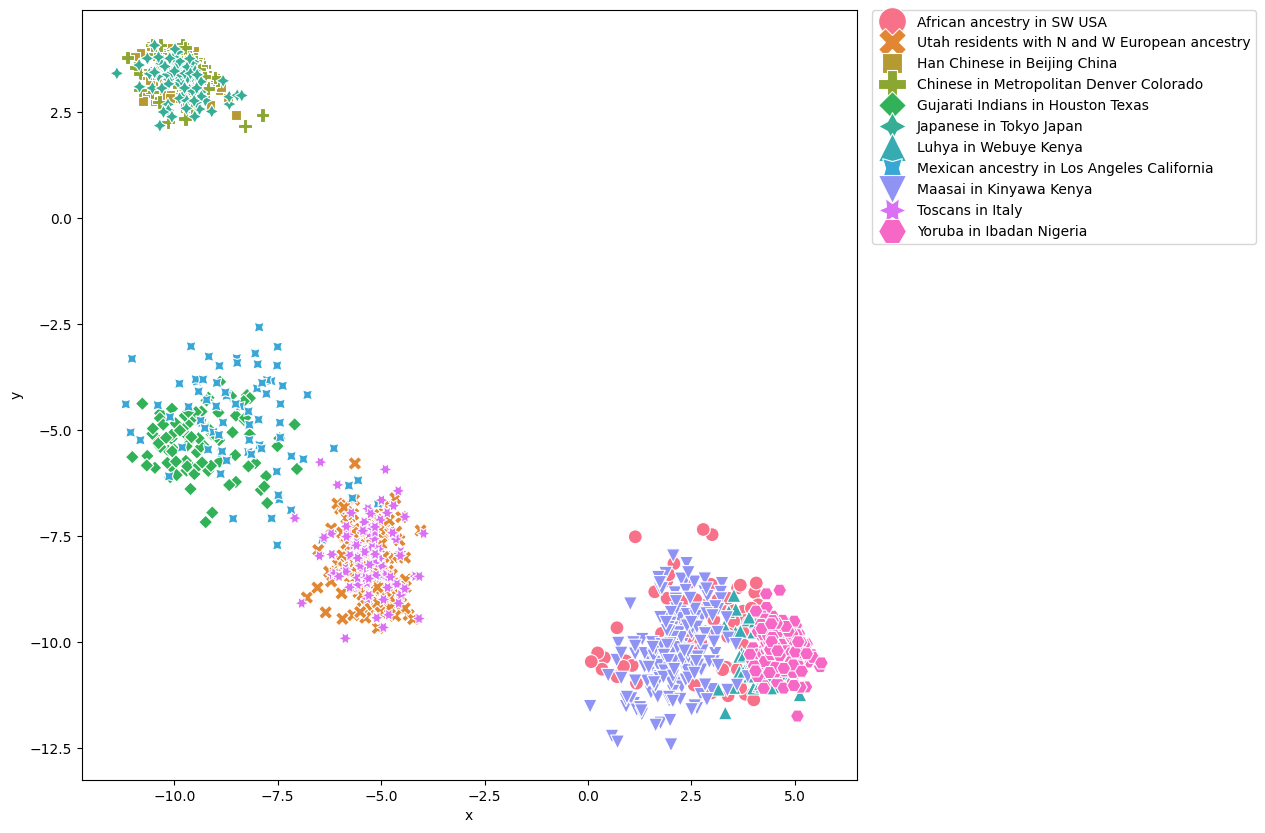

In [24]:
# Introduce 1% missing values encoded as 0
missing_mask = np.random.rand(*geno_data.shape) < 0.01
geno_data_missing = geno_data.copy()
geno_data_missing[missing_mask] = 0
# Test autoencoder embedding with this missing data
embeded_points_missing = encoder_model.predict(geno_data_missing.to_numpy())

x = embeded_points_missing[:,0]
y = embeded_points_missing[:,1]
pop = pheno2['population']
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

The autoencoder has already learned the non-linear manifold of the genetics and acts as a "denoising" algorithm, generally maintaining the separation and robustness of the population embeddings.